In [ ]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.io import read_image
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks/Animais'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Ativei o GPU do colab para treinar mais rápido
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
#Cria função para treinar modelo
def train_model(model, trainloader, valloader, criterion, optimizer, device=device, num_epochs=5):
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accuracies'].append(train_acc)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%')

        # Validação
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct / total
        history['val_losses'].append(val_loss)
        history['val_accuracies'].append(val_acc)
        print(f'Epoch {epoch+1}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.2f}%')

    print('Treinamento concluído')
    return history

#Cria função para plotar os gráficos de treinamento e validação
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train')
    ax1.plot(history['val_losses'], label='Validation')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history['train_accuracies'], label='Train')
    ax2.plot(history['val_accuracies'], label='Validation')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.show()

#Cria função para mostrar a acurácia de teste
def test_model(model, testloader, device=device):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')

In [ ]:
#Cria função para mostrar 5 imagens para poder olhar as tranformações
def show_images(images, titles=None, cols=5):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
example_dir = os.path.join(file_path, 'train') # Define o caminho para o diretório de treino dentro do dataset reduzido.
example_set = datasets.ImageFolder(example_dir, transform=None) # Cria um dataset a partir da pasta de imagens usando o ImageFolder do PyTorch.
# Esse dataset agrupa as imagens por subpastas (cada subpasta representa uma classe).
example_images = [example_set[i][0] for i in random.sample(range(len(example_set)), 5)] # Seleciona 5 imagens aleatórias do conjunto de treino.

transform = transforms.Resize((224, 224)) # Cria uma transformação que redimensiona as imagens para 224x224 pixels.
resized_images = [transform(img) for img in example_images] # Aplica a transformação de redimensionamento a cada imagem da lista 'example_images'.

# Mostrando imagens originais
print("Imagens Originais")
show_images(resized_images)

# Exemplo de RandomResizedCrop
cropped_images = [transforms.RandomResizedCrop(224)(img) for img in resized_images]
print("Após RandomResizedCrop")
show_images(cropped_images)

# Exemplo de RandomHorizontalFlip
flipped_images = [transforms.RandomHorizontalFlip(p=0.5)(img) for img in resized_images]
print("Após RandomHorizontalFlip")
show_images(flipped_images)

# Exemplo de RandomRotation
rotated_images = [transforms.RandomRotation(15)(img) for img in resized_images]
print("Após RandomRotation")
show_images(rotated_images)

# Exemplo de RandomAffine
affined_images = [transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1))(img) for img in resized_images]
print("Após RandomAffine")
show_images(affined_images)

# Exemplo de RandomRotation
rotated_images = [transforms.RandomRotation(degrees=15)(img) for img in resized_images]
print("Após RandomRotation")
show_images(rotated_images)

# Exemplo de ColorJitter
jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02)
jittered_images = [jitter(img) for img in resized_images]
print("Após ColorJitter")
show_images(jittered_images)

# Exemplo de RandomVerticalFlip
vertical_flipped_images = [transforms.RandomVerticalFlip(p=1.0)(img) for img in resized_images]
print("Após RandomVerticalFlip")
show_images(vertical_flipped_images)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Transformações para Data Augmentation para conjunto de treino
transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),# é necessário reduzir as imagens de 512x512 parar 224x224 por causa do modelo pré-treinado que vamos usar: Resnet18
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]) #Normalização das imagens
])

# Transformações sem augmentation para validação
transform_no_aug = transforms.Compose([
    transforms.Resize(230),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Carregando os datasets
train_set = datasets.ImageFolder(os.path.join(file_path, 'train'), transform=transform_aug)
val_set = datasets.ImageFolder(os.path.join(file_path, 'val'), transform=transform_no_aug)

# Loaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=True) # Usei shuffle=True na validação para poder explorar diferentes resultados mais para frente na visualização da imagens

In [ ]:
# Utilizando pesos pré-treinados
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Congelar todas as camadas
for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Substituir a última camada
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

100%|██████████| 5/5 [00:02<00:00,  2.19it/s]


Epoch 1, Train Loss: 1.331, Train Accuracy: 33.33%
Epoch 1, Val Loss: 1.052, Val Accuracy: 42.67%


100%|██████████| 5/5 [00:02<00:00,  2.44it/s]


Epoch 2, Train Loss: 1.179, Train Accuracy: 37.33%
Epoch 2, Val Loss: 0.867, Val Accuracy: 54.00%


100%|██████████| 5/5 [00:02<00:00,  2.43it/s]


...

Epoch 8, Train Loss: 0.392, Train Accuracy: 92.00%
Epoch 8, Val Loss: 0.214, Val Accuracy: 96.67%


100%|██████████| 5/5 [00:02<00:00,  2.45it/s]


Epoch 9, Train Loss: 0.392, Train Accuracy: 91.33%
Epoch 9, Val Loss: 0.202, Val Accuracy: 95.33%


100%|██████████| 5/5 [00:02<00:00,  2.49it/s]


Epoch 10, Train Loss: 0.348, Train Accuracy: 93.33%
Epoch 10, Val Loss: 0.180, Val Accuracy: 96.67%
Treinamento concluído


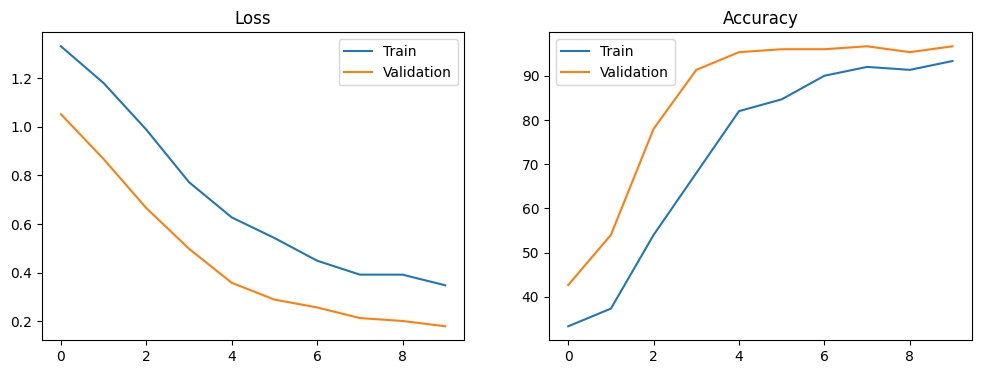

Acurácia da rede na base de teste: 96.67%


In [ ]:
# Treinando a CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10)

plot_history(history)
test_model(model, val_loader)

In [ ]:
# Função para visualizar as imagens com as classificações que o modelo fez
def plot_and_predict(model, image, class_names, device=device):
    model.eval()
    image = image.to(device)
    outputs = model(image.unsqueeze(0))
    _, predicted = torch.max(outputs.data, 1)
    probs = F.softmax(outputs, dim=1)[0] * 100
    prob = probs[predicted].item()

    # image between 0 and 1
    image = torch.clamp(image * 0.225 + 0.45, 0, 1)
    title = f'Classe: {class_names[predicted]} ({prob:.2f}%)'
    plt.imshow(image.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
val_iter = iter(val_loader)
num_batches = len(val_loader)

# Escolhe aleatoriamente um índice de batch entre 0 e o total - 1(para escolher um batch aleatório)
random_batch_idx = random.randint(0, num_batches - 1)

# Avança até o batch escolhido
for _ in range(random_batch_idx):
    next(val_iter)

images, labels = next(val_iter)

for image, label in zip(images, labels):
    plot_and_predict(model, image, val_set.classes)

Output hidden; open in https://colab.research.google.com to view.